# Inisialisasi dan Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Agar plot tampil langsung di notebook
%matplotlib inline

# Fungsi helper untuk menampilkan gambar dengan judul
def tampilkan_citra(images, titles, columns=2):
    plt.figure(figsize=(15, 10))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(len(images) // columns + 1, columns, i + 1)
        if len(img.shape) == 2: # Citra Grayscale
            plt.imshow(img, cmap='gray')
        else: # Citra RGB
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Proses Pemuatan Citra (Asset)

In [2]:
# 1. Load citra tulisan nama dan citra backlight
# Menggunakan [cite: 20, 124]
path_nama = 'nama_maharani.jpeg' # Ganti dengan nama filemu
path_backlight = 'foto_backlight.jpeg' # Ganti dengan nama filemu

img_nama_bgr = cv2.imread(path_nama)
img_backlight_bgr = cv2.imread(path_backlight)

# Konversi ke RGB untuk keperluan display Matplotlib 
img_nama = cv2.cvtColor(img_nama_bgr, cv2.COLOR_BGR2RGB)
img_backlight = cv2.cvtColor(img_backlight_bgr, cv2.COLOR_BGR2RGB)

print("Citra berhasil dimuat.")

Citra berhasil dimuat.


# Soal 1: Ekstraksi Kanal Warna dan Deteksi

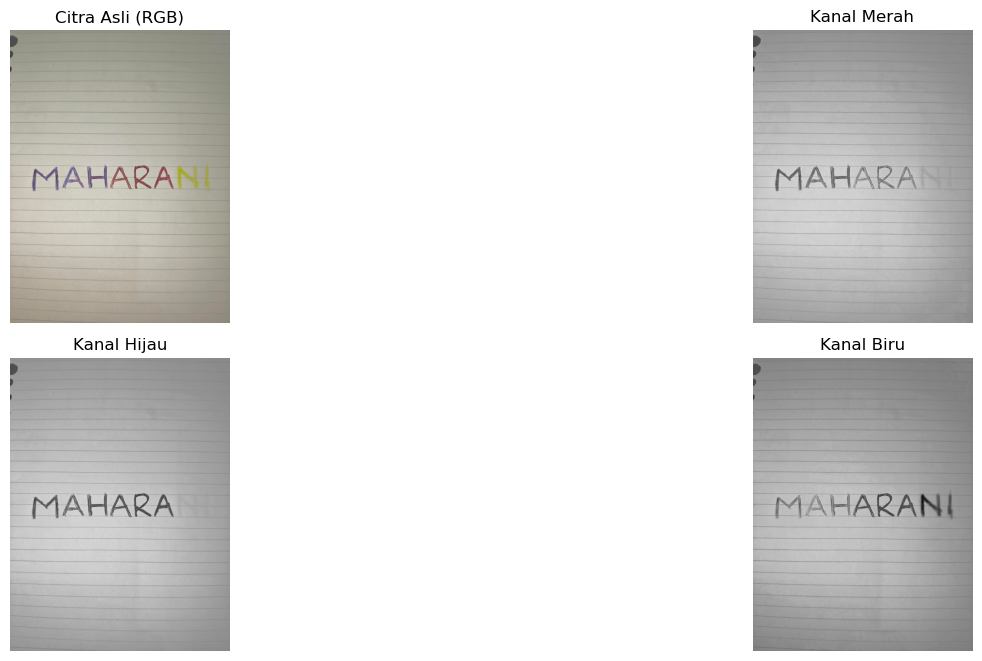

In [3]:
# a) Deteksi warna pada citra (Kanal R, G, B) 
r, g, b = cv2.split(img_nama)

# Menyiapkan list untuk ditampilkan
citra_kanal = [img_nama, r, g, b]
judul_kanal = ['Citra Asli (RGB)', 'Kanal Merah', 'Kanal Hijau', 'Kanal Biru']

tampilkan_citra(citra_kanal, judul_kanal)

# Soal 1: Thresholding (Ambang Batas) dan Histogram

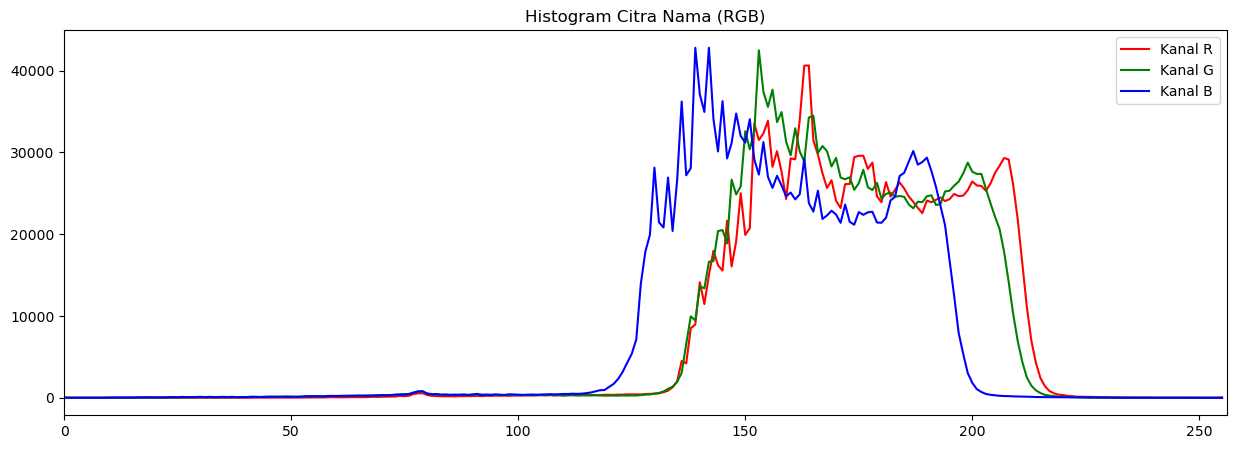

In [4]:
# e) Mencari Nilai Ambang Batas 
# Catatan: Nilai 150 adalah contoh, kamu harus sesuaikan dengan hasil gambarmu
ret, thresh_merah = cv2.threshold(r, 150, 255, cv2.THRESH_BINARY_INV)
ret, thresh_hijau = cv2.threshold(g, 150, 255, cv2.THRESH_BINARY_INV)
ret, thresh_biru = cv2.threshold(b, 150, 255, cv2.THRESH_BINARY_INV)

# c) Membuat dan Menampilkan Histogram 
plt.figure(figsize=(15, 5))
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_nama], [i], None, [256], [0, 256])
    plt.plot(hist, color=col, label=f'Kanal {col.upper()}')
    plt.xlim([0, 256])

plt.title('Histogram Citra Nama (RGB)')
plt.legend()
plt.show()

# Soal 2: Perbaikan Citra Backlight (Operasi Pixel)

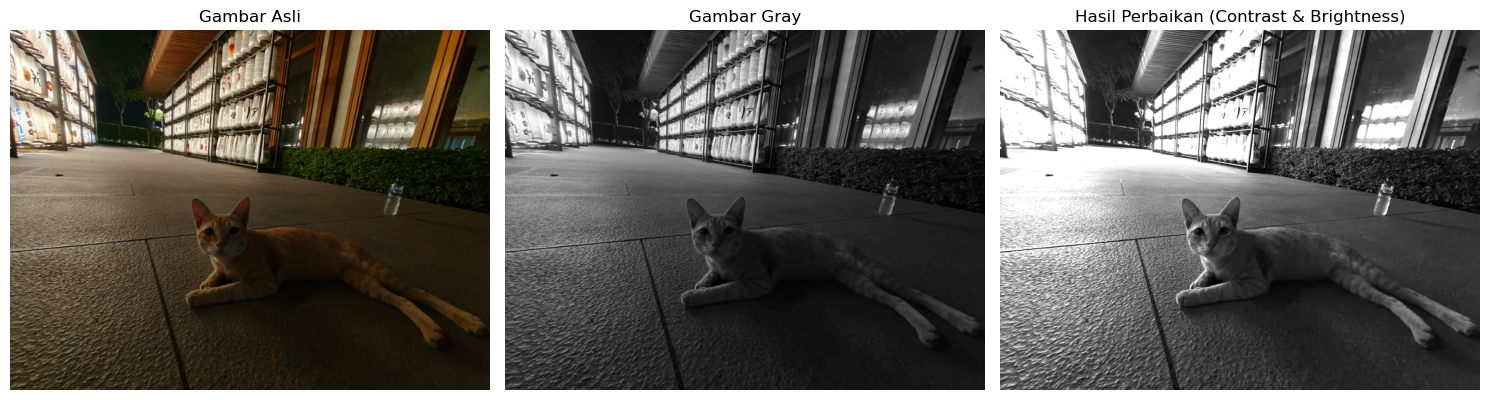

In [5]:
# c) Konversi gambar menjadi grayscale [cite: 128]
gray_back = cv2.cvtColor(img_backlight_bgr, cv2.COLOR_BGR2GRAY)

# d) Meningkatkan kecerahan dan kontras [cite: 128]
# f(x) = alpha * g(x) + beta
# alpha > 1 (Kontras), beta > 0 (Brightness)
alpha = 1.6 # Sesuaikan agar tidak color burn 
beta = 40

img_enhanced = cv2.convertScaleAbs(gray_back, alpha=alpha, beta=beta)

# Visualisasi perbandingan sesuai contoh [cite: 132, 133, 134, 135, 136]
backlight_results = [img_backlight, gray_back, img_enhanced]
backlight_titles = ['Gambar Asli', 'Gambar Gray', 'Hasil Perbaikan (Contrast & Brightness)']

tampilkan_citra(backlight_results, backlight_titles, columns=3)